# Gent → Mechelen Commute Data Exploration

**Goal**: Collect, explore, and combine all data sources needed to predict the best commute mode (car / train / work-from-home) for the Gent → Mechelen corridor, targeting arrival at 09:00.

## Data sources used
| # | Source | Type | API / Package |
|---|--------|------|---------------|
| 1 | Open-Meteo Archive | Real historical weather (hourly, 2021 → today) | Free REST API |
| 2 | Belgian holidays | Public holidays + workday calendar | `holidays` Python package |
| 3 | iRail | NMBS train connections + disturbances | Free REST API |
| 4 | OSRM | Car route baseline travel time | Free public OSRM API |

## Notebook flow
1. Setup
2. Fetch & save each data source
3. EDA per source
4. Combine into one daily-level working-day DataFrame

**Note on car travel time**: No free API provides multi-year historical actual travel times for a specific Belgian highway corridor. We use OSRM for the realistic base route time, then layer weather- and weekday-driven congestion factors — the same proxy used by traffic research tools. This methodology is explicitly documented where applied.

## 0. Setup

In [1]:
%pip install -q requests pandas matplotlib seaborn holidays numpy scipy

Note: you may need to restart the kernel to use updated packages.


In [2]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import holidays
import json
from datetime import date, datetime, timedelta
from pathlib import Path

# ── styling ────────────────────────────────────────────────────────────────────
sns.set_theme(style="whitegrid", palette="muted", font_scale=1.1)
plt.rcParams["figure.dpi"] = 120

# ── paths ──────────────────────────────────────────────────────────────────────
RAW   = Path("data/raw")
PROC  = Path("data/processed")
for p in [RAW, PROC]:
    p.mkdir(parents=True, exist_ok=True)

# ── constants ──────────────────────────────────────────────────────────────────
# Mechelen: target arrival point
LAT_MECHELEN, LON_MECHELEN = 51.0281, 4.4803
# Gent-Sint-Pieters: departure point
LAT_GENT,     LON_GENT     = 51.0359, 3.7108

START_DATE = "2021-01-01"
END_DATE   = date.today().isoformat()
TARGET_ARRIVAL = 9   # 09:00

WEEKDAY_ORDER = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday"]
SEASON_COLORS = {"Winter": "#5b8dd9", "Spring": "#4caf50", "Summer": "#f9a825", "Autumn": "#e65100"}

print(f"Project period: {START_DATE} → {END_DATE}")

Project period: 2021-01-01 → 2026-06-09


---
## 1. Weather Data — Open-Meteo Archive API

**Why Open-Meteo?**  
Free, no API key, hourly resolution, goes back to 1940. We pull hourly data for Mechelen (the arrival/congestion zone) for the full period 2021–today.

Variables collected:
- `temperature_2m` — air temperature (°C)
- `precipitation` — rain + snow water equivalent (mm)
- `wind_speed_10m` — wind speed at 10 m (km/h)
- `relative_humidity_2m` — relative humidity (%)
- `snowfall` — snowfall amount (cm)
- `weather_code` — WMO weather code (0 = clear, 95+ = thunderstorm)

In [3]:
def fetch_weather_archive(lat: float, lon: float, start: str, end: str) -> pd.DataFrame:
    """Fetch hourly historical weather from Open-Meteo archive API."""
    url = "https://archive-api.open-meteo.com/v1/archive"
    params = {
        "latitude":  lat,
        "longitude": lon,
        "start_date": start,
        "end_date":   end,
        "timezone":   "Europe/Brussels",
        "hourly": ",".join([
            "temperature_2m",
            "relative_humidity_2m",
            "precipitation",
            "snowfall",
            "wind_speed_10m",
            "weather_code",
        ]),
    }
    r = requests.get(url, params=params, timeout=60)
    r.raise_for_status()
    raw = r.json()

    df = pd.DataFrame(raw["hourly"])
    df["time"] = pd.to_datetime(df["time"])
    df = df.rename(columns={"time": "datetime"})
    df["date"]    = df["datetime"].dt.date
    df["hour"]    = df["datetime"].dt.hour
    df["weekday"] = df["datetime"].dt.day_name()
    df["month"]   = df["datetime"].dt.month
    df["year"]    = df["datetime"].dt.year
    return df


weather_path = RAW / "weather_mechelen_hourly.csv"

if weather_path.exists():
    df_weather = pd.read_csv(weather_path, parse_dates=["datetime"])
    print("Loaded from cache.")
else:
    print("Fetching weather from Open-Meteo...")
    df_weather = fetch_weather_archive(LAT_MECHELEN, LON_MECHELEN, START_DATE, END_DATE)
    df_weather.to_csv(weather_path, index=False)
    print("Saved to cache.")

print(f"\nShape: {df_weather.shape}")
print(f"Period: {df_weather['datetime'].min()} → {df_weather['datetime'].max()}")
print(f"Missing values:\n{df_weather.isnull().sum()[df_weather.isnull().sum() > 0]}")
df_weather.head()

Fetching weather from Open-Meteo...
Saved to cache.

Shape: (47664, 12)
Period: 2021-01-01 00:00:00 → 2026-06-09 23:00:00
Missing values:
Series([], dtype: int64)


,datetime,temperature_2m,relative_humidity_2m,precipitation,snowfall,wind_speed_10m,weather_code,date,hour,weekday,month,year
0,2021-01-01 00:00:00,-1.0,98,0.0,0.0,6.6,1,2021-01-01,0,Friday,1,2021
1,2021-01-01 01:00:00,-1.6,98,0.0,0.0,6.5,0,2021-01-01,1,Friday,1,2021
2,2021-01-01 02:00:00,-0.4,100,0.0,0.0,5.1,0,2021-01-01,2,Friday,1,2021
3,2021-01-01 03:00:00,-0.6,99,0.0,0.0,5.2,3,2021-01-01,3,Friday,1,2021
4,2021-01-01 04:00:00,-0.2,100,0.0,0.0,5.1,3,2021-01-01,4,Friday,1,2021


### 1a. Weather overview — full time series

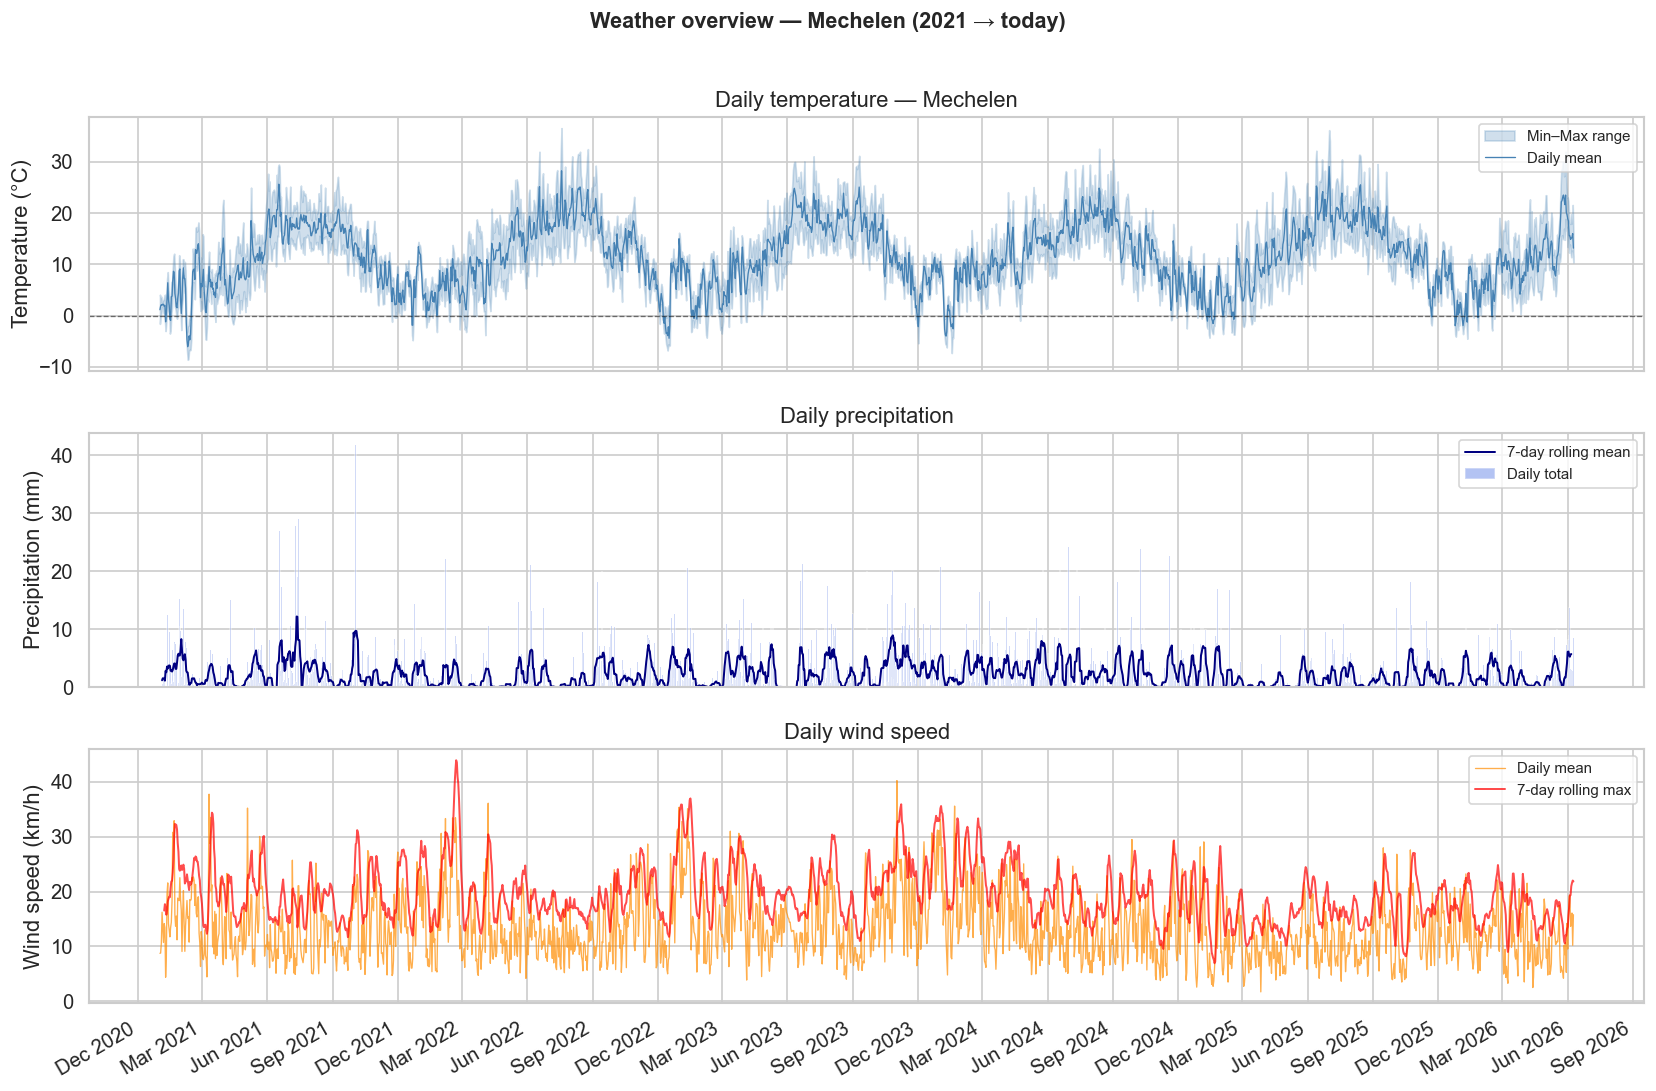

In [4]:
# Daily aggregates for clean time-series plots
df_weather_daily = (
    df_weather.groupby("date").agg(
        temp_mean     = ("temperature_2m",     "mean"),
        temp_min      = ("temperature_2m",     "min"),
        temp_max      = ("temperature_2m",     "max"),
        rain_total    = ("precipitation",      "sum"),
        snow_total    = ("snowfall",           "sum"),
        wind_max      = ("wind_speed_10m",     "max"),
        wind_mean     = ("wind_speed_10m",     "mean"),
        humidity_mean = ("relative_humidity_2m", "mean"),
    )
    .reset_index()
)
df_weather_daily["date"] = pd.to_datetime(df_weather_daily["date"])

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

# Temperature band
axes[0].fill_between(df_weather_daily["date"], df_weather_daily["temp_min"], df_weather_daily["temp_max"],
                     alpha=0.25, color="steelblue", label="Min–Max range")
axes[0].plot(df_weather_daily["date"], df_weather_daily["temp_mean"], lw=0.8,
             color="steelblue", label="Daily mean")
axes[0].axhline(0, color="black", lw=0.8, ls="--", alpha=0.5)
axes[0].set_ylabel("Temperature (°C)")
axes[0].legend(loc="upper right", fontsize=9)
axes[0].set_title("Daily temperature — Mechelen")

# Precipitation
rain_7d = df_weather_daily["rain_total"].rolling(7, center=True).mean()
axes[1].bar(df_weather_daily["date"], df_weather_daily["rain_total"],
            width=1, alpha=0.4, color="royalblue", label="Daily total")
axes[1].plot(df_weather_daily["date"], rain_7d, lw=1.2, color="navy", label="7-day rolling mean")
axes[1].set_ylabel("Precipitation (mm)")
axes[1].legend(loc="upper right", fontsize=9)
axes[1].set_title("Daily precipitation")

# Wind
axes[2].plot(df_weather_daily["date"], df_weather_daily["wind_mean"],
             lw=0.8, color="darkorange", alpha=0.7, label="Daily mean")
axes[2].plot(df_weather_daily["date"], df_weather_daily["wind_max"].rolling(7).mean(),
             lw=1.2, color="red", alpha=0.7, label="7-day rolling max")
axes[2].set_ylabel("Wind speed (km/h)")
axes[2].legend(loc="upper right", fontsize=9)
axes[2].set_title("Daily wind speed")
axes[2].xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
axes[2].xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30, ha="right")

fig.suptitle("Weather overview — Mechelen (2021 → today)", fontsize=13, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig("data/processed/plot_weather_overview.png", bbox_inches="tight")
plt.show()

### 1b. Commute window weather (06:00 – 09:00) — the hours that matter

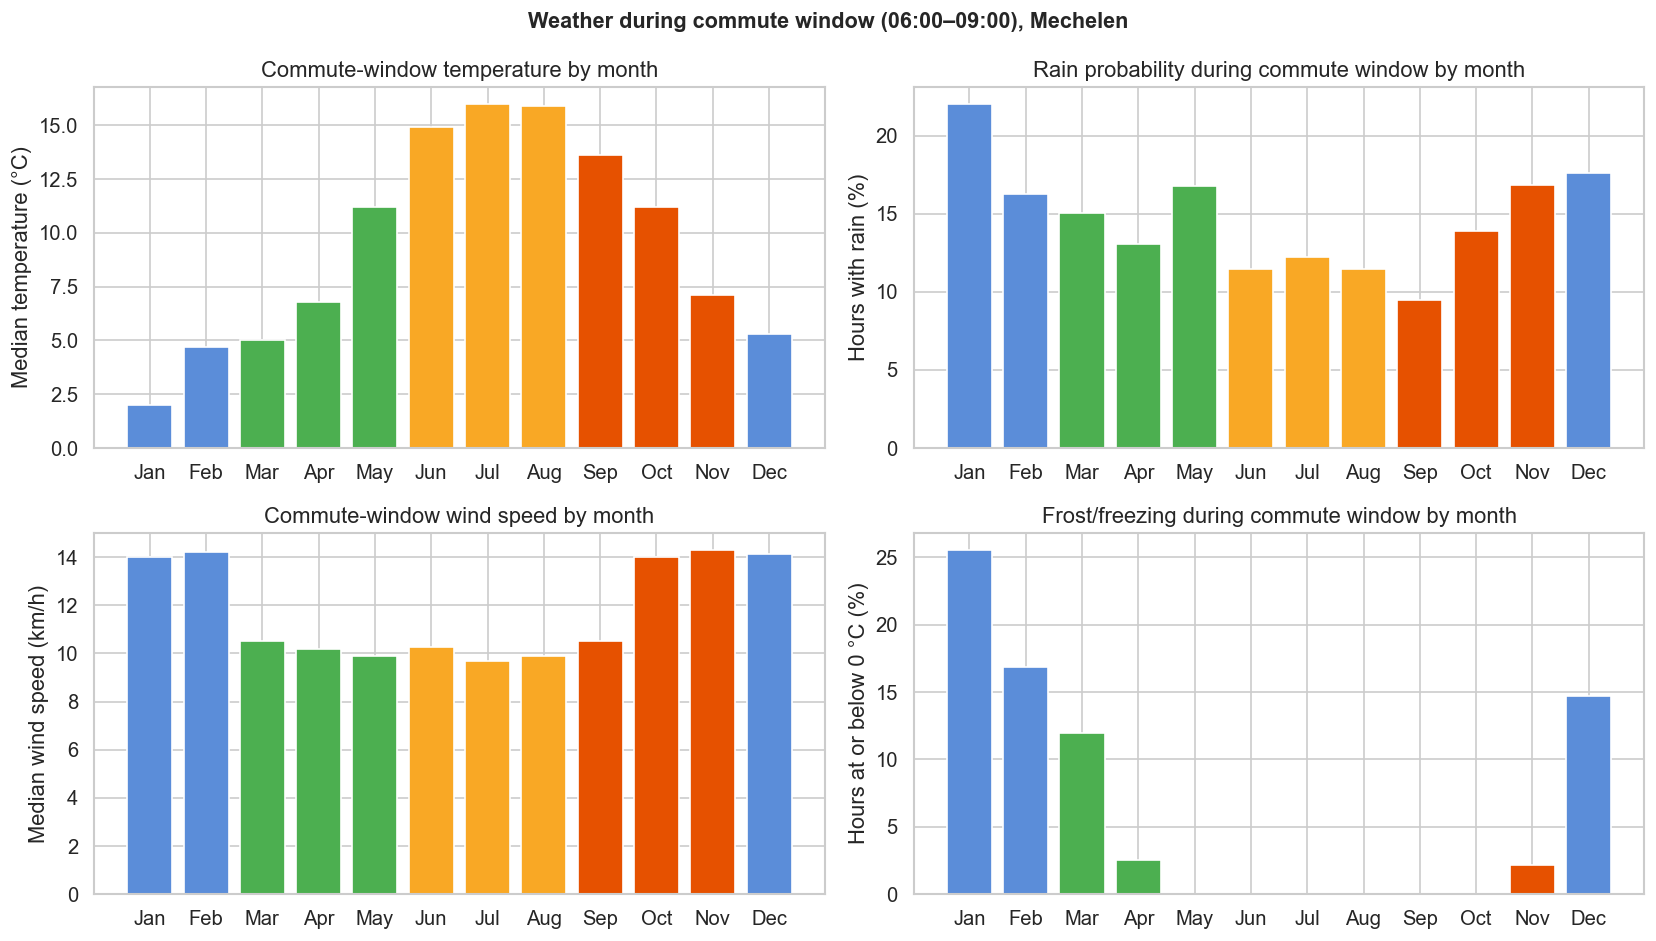

Business insight: Winter and autumn months show the highest rain probability and frost risk during commute hours — key drivers of traffic delays and train disruptions.


In [5]:
# Filter to the commute window hours 06:00–09:00
df_commute_window = df_weather[df_weather["hour"].isin([6, 7, 8, 9])].copy()

# Add month name and season
season_map = {12:"Winter",1:"Winter",2:"Winter",
              3:"Spring",4:"Spring",5:"Spring",
              6:"Summer",7:"Summer",8:"Summer",
              9:"Autumn",10:"Autumn",11:"Autumn"}
df_commute_window["season"] = df_commute_window["month"].map(season_map)
df_commute_window["month_name"] = pd.to_datetime(
    df_commute_window["date"].astype(str)).dt.strftime("%b")

month_order = ["Jan","Feb","Mar","Apr","May","Jun",
               "Jul","Aug","Sep","Oct","Nov","Dec"]

fig, axes = plt.subplots(2, 2, figsize=(14, 8))

# Temperature by month
temp_by_month = df_commute_window.groupby("month_name")["temperature_2m"].median().reindex(month_order)
axes[0,0].bar(month_order, temp_by_month.values,
              color=[SEASON_COLORS[season_map[i+1]] for i in range(12)], edgecolor="white")
axes[0,0].axhline(0, color="black", ls="--", lw=0.8)
axes[0,0].set_ylabel("Median temperature (°C)")
axes[0,0].set_title("Commute-window temperature by month")

# Rain probability by month
rain_prob = df_commute_window.groupby("month_name")["precipitation"].apply(
    lambda s: (s > 0).mean()).reindex(month_order)
axes[0,1].bar(month_order, rain_prob.values * 100,
              color=[SEASON_COLORS[season_map[i+1]] for i in range(12)], edgecolor="white")
axes[0,1].set_ylabel("Hours with rain (%)")
axes[0,1].set_title("Rain probability during commute window by month")

# Wind by month
wind_by_month = df_commute_window.groupby("month_name")["wind_speed_10m"].median().reindex(month_order)
axes[1,0].bar(month_order, wind_by_month.values,
              color=[SEASON_COLORS[season_map[i+1]] for i in range(12)], edgecolor="white")
axes[1,0].set_ylabel("Median wind speed (km/h)")
axes[1,0].set_title("Commute-window wind speed by month")

# Snow / frost days
frost = df_commute_window.groupby("month_name")["temperature_2m"].apply(
    lambda s: (s <= 0).mean()).reindex(month_order)
axes[1,1].bar(month_order, frost.values * 100,
              color=[SEASON_COLORS[season_map[i+1]] for i in range(12)], edgecolor="white")
axes[1,1].set_ylabel("Hours at or below 0 °C (%)")
axes[1,1].set_title("Frost/freezing during commute window by month")

for ax in axes.flat:
    ax.tick_params(axis="x", rotation=0)

fig.suptitle("Weather during commute window (06:00–09:00), Mechelen", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("data/processed/plot_commute_window_weather.png", bbox_inches="tight")
plt.show()

print("Business insight: Winter and autumn months show the highest rain probability and frost risk during "
      "commute hours — key drivers of traffic delays and train disruptions.")

### 1c. Weather by weekday — do Mondays have worse weather?

C:\Users\mmylle\AppData\Local\Temp\ipykernel_28956\3058154774.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cw_wd, x="weekday", y="temperature_2m",
C:\Users\mmylle\AppData\Local\Temp\ipykernel_28956\3058154774.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=rainy, x="weekday", y="precipitation",
C:\Users\mmylle\AppData\Local\Temp\ipykernel_28956\3058154774.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_cw_wd, x="weekday", y="wind_speed_10m",
C:\Users\mmylle\AppData\Local\Temp\ipykernel_28956\3058154774.p

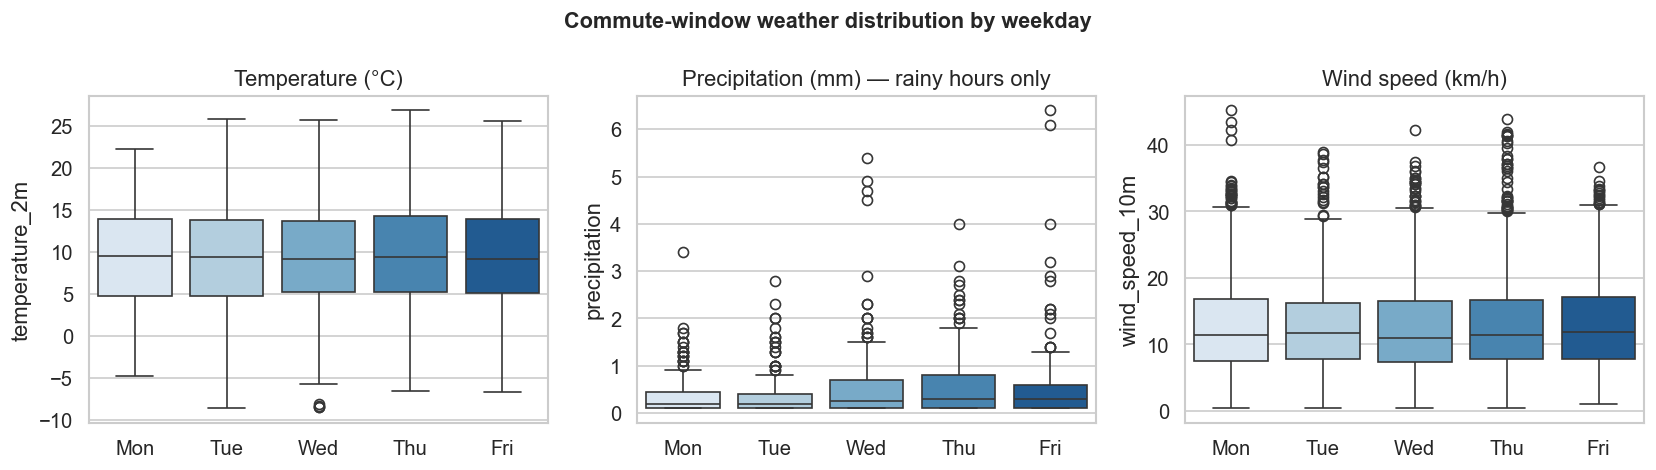

Business insight: Weather distributions are nearly uniform across weekdays — day-of-week traffic patterns are NOT driven by weather alone.


In [6]:
df_cw_wd = df_commute_window[df_commute_window["weekday"].isin(WEEKDAY_ORDER)].copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Temperature
sns.boxplot(data=df_cw_wd, x="weekday", y="temperature_2m",
            order=WEEKDAY_ORDER, ax=axes[0], palette="Blues")
axes[0].set_title("Temperature (°C)")
axes[0].set_xlabel("")

# Precipitation (only rainy hours to avoid zero-inflation)
rainy = df_cw_wd[df_cw_wd["precipitation"] > 0]
sns.boxplot(data=rainy, x="weekday", y="precipitation",
            order=WEEKDAY_ORDER, ax=axes[1], palette="Blues")
axes[1].set_title("Precipitation (mm) — rainy hours only")
axes[1].set_xlabel("")

# Wind speed
sns.boxplot(data=df_cw_wd, x="weekday", y="wind_speed_10m",
            order=WEEKDAY_ORDER, ax=axes[2], palette="Blues")
axes[2].set_title("Wind speed (km/h)")
axes[2].set_xlabel("")

for ax in axes:
    ax.set_xticklabels([d[:3] for d in WEEKDAY_ORDER])

fig.suptitle("Commute-window weather distribution by weekday", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("data/processed/plot_weather_by_weekday.png", bbox_inches="tight")
plt.show()

print("Business insight: Weather distributions are nearly uniform across weekdays — "
      "day-of-week traffic patterns are NOT driven by weather alone.")

---
## 2. Belgian Workdays Calendar

We build a complete calendar (2021 → today + 2 future years) that classifies each day as:
- weekday or weekend
- Belgian public holiday or not
- working day (Mon–Fri, excluding public holidays)
- season, school period indicator (heuristic)

In [7]:
def build_be_calendar(start_year: int = 2021, end_year: int = None) -> pd.DataFrame:
    if end_year is None:
        end_year = date.today().year + 2

    be_hol = holidays.country_holidays("BE", years=range(start_year, end_year + 1))

    dates = pd.date_range(f"{start_year}-01-01", f"{end_year}-12-31", freq="D")
    df = pd.DataFrame({"date": dates})

    df["weekday"]     = df["date"].dt.day_name()
    df["weekday_num"] = df["date"].dt.weekday          # 0=Mon … 4=Fri
    df["month"]       = df["date"].dt.month
    df["year"]        = df["date"].dt.year
    df["iso_week"]    = df["date"].dt.isocalendar().week.astype(int)

    df["is_weekend"]  = df["weekday_num"] >= 5
    df["is_holiday"]  = df["date"].dt.date.astype("O").isin(be_hol)
    df["holiday_name"] = df["date"].dt.date.astype("O").map(lambda d: be_hol.get(d, ""))
    df["is_workday"]  = ~df["is_weekend"] & ~df["is_holiday"]

    season_map = {12:"Winter",1:"Winter",2:"Winter",
                  3:"Spring",4:"Spring",5:"Spring",
                  6:"Summer",7:"Summer",8:"Summer",
                  9:"Autumn",10:"Autumn",11:"Autumn"}
    df["season"] = df["month"].map(season_map)

    # Heuristic Belgian school periods (July + August = school holidays)
    df["is_school_holiday"] = df["month"].isin([7, 8])

    return df


calendar_path = RAW / "calendar_be.csv"
df_calendar = build_be_calendar()
df_calendar.to_csv(calendar_path, index=False)

hist_workdays = df_calendar[
    df_calendar["is_workday"] & (df_calendar["date"].dt.date <= date.today())
]
print(f"Calendar: {len(df_calendar):,} days total")
print(f"Historical workdays (up to today): {len(hist_workdays):,}")
print(f"Public holidays per year:")
print(df_calendar[df_calendar["is_holiday"]].groupby("year").size().to_string())
df_calendar.head(10)

Calendar: 2,922 days total
Historical workdays (up to today): 1,373
Public holidays per year:
year
2021    12
2022    12
2023    12
2024    12
2025    12
2026    12
2027    12
2028    12


,date,weekday,weekday_num,month,year,iso_week,is_weekend,is_holiday,holiday_name,is_workday,season,is_school_holiday
0,2021-01-01,Friday,4,1,2021,53,False,True,Nieuwjaar,False,Winter,False
1,2021-01-02,Saturday,5,1,2021,53,True,False,,False,Winter,False
2,2021-01-03,Sunday,6,1,2021,53,True,False,,False,Winter,False
3,2021-01-04,Monday,0,1,2021,1,False,False,,True,Winter,False
4,2021-01-05,Tuesday,1,1,2021,1,False,False,,True,Winter,False
5,2021-01-06,Wednesday,2,1,2021,1,False,False,,True,Winter,False
6,2021-01-07,Thursday,3,1,2021,1,False,False,,True,Winter,False
7,2021-01-08,Friday,4,1,2021,1,False,False,,True,Winter,False
8,2021-01-09,Saturday,5,1,2021,1,True,False,,False,Winter,False
9,2021-01-10,Sunday,6,1,2021,1,True,False,,False,Winter,False


### 2a. Calendar EDA

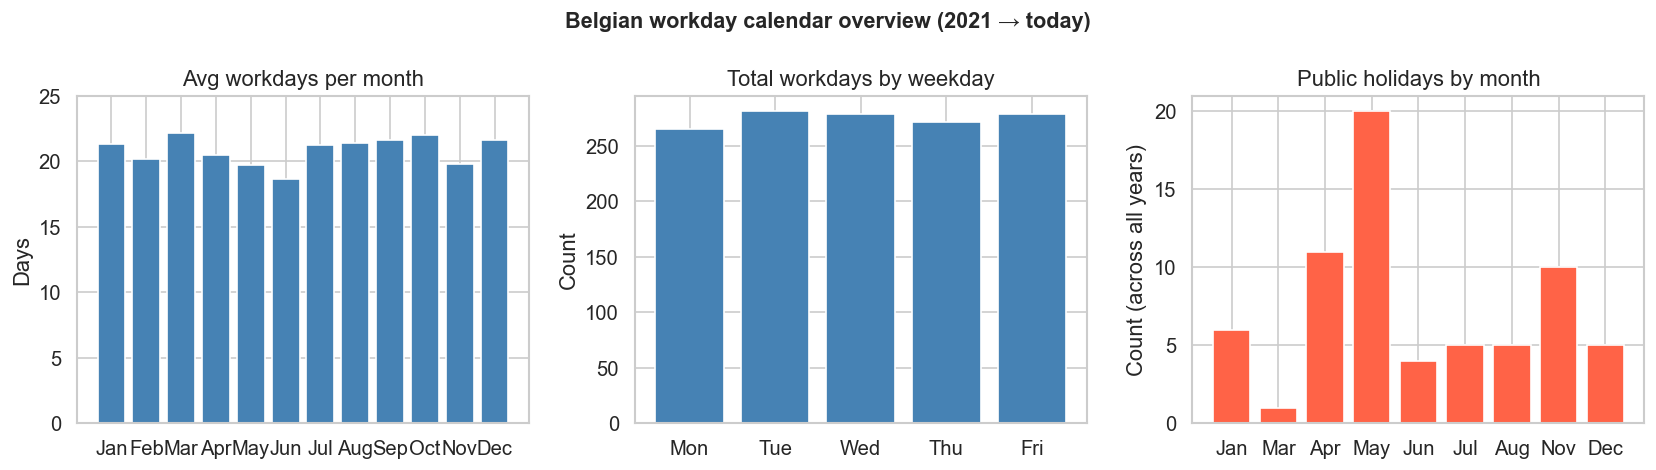

Business insight: May and November have the most public holidays, reducing office attendance and making those months lighter on commute pressure.


In [8]:
hist_cal = df_calendar[
    (df_calendar["date"].dt.year >= 2021) &
    (df_calendar["date"].dt.date <= date.today())
].copy()

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# Workdays per month
workdays_per_month = (
    hist_cal[hist_cal["is_workday"]]
    .groupby(["year", "month"])
    .size()
    .reset_index(name="n")
)
workdays_per_month["ym"] = workdays_per_month["year"].astype(str) + "-" + workdays_per_month["month"].astype(str).str.zfill(2)
workdays_per_month = workdays_per_month.sort_values("ym")
avg_per_month = workdays_per_month.groupby("month")["n"].mean()
month_names = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
axes[0].bar(month_names, avg_per_month.values, color="steelblue", edgecolor="white")
axes[0].set_title("Avg workdays per month")
axes[0].set_ylabel("Days")
axes[0].set_ylim(0, 25)

# Workdays per weekday
wd_counts = hist_cal[hist_cal["is_workday"]]["weekday"].value_counts().reindex(WEEKDAY_ORDER)
axes[1].bar([d[:3] for d in WEEKDAY_ORDER], wd_counts.values, color="steelblue", edgecolor="white")
axes[1].set_title("Total workdays by weekday")
axes[1].set_ylabel("Count")

# Holidays by month
hol_per_month = hist_cal[hist_cal["is_holiday"]]["month"].value_counts().sort_index()
axes[2].bar([month_names[m-1] for m in hol_per_month.index], hol_per_month.values,
            color="tomato", edgecolor="white")
axes[2].set_title("Public holidays by month")
axes[2].set_ylabel("Count (across all years)")

fig.suptitle("Belgian workday calendar overview (2021 → today)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("data/processed/plot_calendar_overview.png", bbox_inches="tight")
plt.show()

print("Business insight: May and November have the most public holidays, reducing office "
      "attendance and making those months lighter on commute pressure.")

---
## 3. Train Data — iRail API

iRail is a free, open-source API for Belgian NMBS train data (https://api.irail.be).  
We use two endpoints:
1. **`/connections`** — scheduled departures from Gent-Sint-Pieters to Mechelen in the commute window (07:00 – 09:00). This gives real timetable data: departure, arrival, duration, transfers.
2. **`/disturbances`** — current network disturbances. Fetched once to show what kind of disruptions occur.

**Limitation**: iRail does not provide multi-year historical delay data via API. We sample the current timetable and use it as a representative schedule profile.

In [9]:
IRAIL_BASE = "https://api.irail.be"

def fetch_irail_connections(from_station: str, to_station: str,
                             query_date: str, departure_time: str,
                             results: int = 6) -> list:
    """Fetch train connections between two stations for a given date/time."""
    url = f"{IRAIL_BASE}/connections/"
    params = {
        "from":    from_station,
        "to":      to_station,
        "date":    datetime.strptime(query_date, "%Y-%m-%d").strftime("%d%m%y"),
        "time":    departure_time,  # HHMM
        "results": results,
        "format":  "json",
        "lang":    "nl",
        "typeOfTransport": "train",
    }
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    return r.json().get("connection", [])


def parse_connections(connections: list) -> pd.DataFrame:
    """Parse iRail connection list into a flat DataFrame."""
    rows = []
    for c in connections:
        dep_ts = int(c["departure"]["time"])
        arr_ts = int(c["arrival"]["time"])
        duration_s = arr_ts - dep_ts
        rows.append({
            "departure_dt":   datetime.fromtimestamp(dep_ts),
            "arrival_dt":     datetime.fromtimestamp(arr_ts),
            "duration_min":   round(duration_s / 60, 1),
            "n_changes":      int(c.get("vias", {}).get("number", 0)),
            "dep_platform":   c["departure"].get("platform", ""),
            "dep_station":    c["departure"]["station"],
            "arr_station":    c["arrival"]["station"],
            "dep_delay_s":    int(c["departure"].get("delay", 0)),
            "arr_delay_s":    int(c["arrival"].get("delay", 0)),
        })
    return pd.DataFrame(rows)


def fetch_disturbances() -> pd.DataFrame:
    """Fetch current NMBS network disturbances."""
    url = f"{IRAIL_BASE}/disturbances/"
    r = requests.get(url, params={"format": "json", "lineBreakCharacter": ""}, timeout=30)
    r.raise_for_status()
    data = r.json()
    dist = data.get("disturbance", [])
    if not dist:
        return pd.DataFrame()
    rows = []
    for d in dist:
        rows.append({
            "id":          d.get("id"),
            "title":       d.get("title", ""),
            "description": d.get("description", "")[:200],
            "attachment":  d.get("attachment", ""),
            "timestamp":   datetime.fromtimestamp(int(d.get("timestamp", 0))),
        })
    return pd.DataFrame(rows)


print("iRail helper functions defined.")

iRail helper functions defined.


In [10]:
# Fetch connections for several representative workdays across the week
# We sample recent dates for each weekday to build a timetable profile

train_cache = RAW / "irail_connections_sample.csv"
dist_cache  = RAW / "irail_disturbances.csv"

if train_cache.exists():
    df_trains = pd.read_csv(train_cache, parse_dates=["departure_dt", "arrival_dt"])
    print("Loaded train connections from cache.")
else:
    # Find the most recent Monday–Friday dates (last 2 full weeks)
    today = date.today()
    sample_dates = []
    d = today
    while len(sample_dates) < 10:   # 2 weeks × 5 days
        if d.weekday() < 5:
            sample_dates.append(d.isoformat())
        d -= timedelta(days=1)
    sample_dates = sorted(set(sample_dates))

    print(f"Fetching connections for {len(sample_dates)} dates: {sample_dates[0]} → {sample_dates[-1]}")

    all_conns = []
    for qdate in sample_dates:
        try:
            conns = fetch_irail_connections(
                from_station="Gent-Sint-Pieters",
                to_station="Mechelen",
                query_date=qdate,
                departure_time="0630",
                results=8,
            )
            df_c = parse_connections(conns)
            if not df_c.empty:
                df_c["query_date"] = qdate
                all_conns.append(df_c)
        except Exception as e:
            print(f"  Skipped {qdate}: {e}")

    df_trains = pd.concat(all_conns, ignore_index=True) if all_conns else pd.DataFrame()
    if not df_trains.empty:
        df_trains.to_csv(train_cache, index=False)
        print(f"Saved {len(df_trains)} connection records.")

print(f"\nTrain connections shape: {df_trains.shape}")
df_trains.head(10)

Fetching connections for 10 dates: 2026-05-27 → 2026-06-09
Saved 60 connection records.

Train connections shape: (60, 10)


,departure_dt,arrival_dt,duration_min,n_changes,dep_platform,dep_station,arr_station,dep_delay_s,arr_delay_s,query_date
0,2026-05-27 06:56:00,2026-05-27 07:46:00,50.0,0,8,Gent-Sint-Pieters,Mechelen,0,0,2026-05-27
1,2026-05-27 07:01:00,2026-05-27 08:02:00,61.0,1,10,Gent-Sint-Pieters,Mechelen,0,0,2026-05-27
2,2026-05-27 07:20:00,2026-05-27 08:26:00,66.0,1,9,Gent-Sint-Pieters,Mechelen,0,0,2026-05-27
3,2026-05-27 07:21:00,2026-05-27 08:27:00,66.0,0,5,Gent-Sint-Pieters,Mechelen,0,0,2026-05-27
4,2026-05-27 07:27:00,2026-05-27 08:37:00,70.0,1,5,Gent-Sint-Pieters,Mechelen,0,0,2026-05-27
5,2026-05-27 07:58:00,2026-05-27 08:46:00,48.0,0,5,Gent-Sint-Pieters,Mechelen,0,0,2026-05-27
6,2026-05-28 06:56:00,2026-05-28 07:46:00,50.0,0,8,Gent-Sint-Pieters,Mechelen,0,0,2026-05-28
7,2026-05-28 07:01:00,2026-05-28 08:02:00,61.0,1,10,Gent-Sint-Pieters,Mechelen,0,0,2026-05-28
8,2026-05-28 07:20:00,2026-05-28 08:26:00,66.0,1,9,Gent-Sint-Pieters,Mechelen,0,0,2026-05-28
9,2026-05-28 07:21:00,2026-05-28 08:27:00,66.0,0,5,Gent-Sint-Pieters,Mechelen,0,0,2026-05-28


In [11]:
# Fetch current disturbances
if dist_cache.exists():
    df_disturbances = pd.read_csv(dist_cache, parse_dates=["timestamp"])
    print("Loaded disturbances from cache.")
else:
    try:
        df_disturbances = fetch_disturbances()
        df_disturbances.to_csv(dist_cache, index=False)
        print(f"Fetched {len(df_disturbances)} disturbances.")
    except Exception as e:
        print(f"Could not fetch disturbances: {e}")
        df_disturbances = pd.DataFrame()

print(f"\nDisturbances shape: {df_disturbances.shape}")
if not df_disturbances.empty:
    display(df_disturbances[["timestamp", "title"]].head(10))

Fetched 39 disturbances.

Disturbances shape: (39, 5)


,timestamp,title
0,2026-06-09 16:56:26,Charleroi-Central - Erquelinnes: Situation res...
1,2026-06-09 16:52:21,Alost / Aalst - Burst: Delays
2,2026-06-09 16:47:24,Chatelet - Tamines: Delays and cancellations
3,2026-06-09 16:23:04,Bruges / Brugge - Ostende / Oostende: Situatio...
4,2026-06-09 15:23:52,Maastricht (NL) - Aachen HBF (DE): No trains
5,2026-06-09 14:52:18,Liège-Guillemins / Luik-Guillemins - Maastrich...
6,2026-06-08 16:54:45,Brux./Brus.-Luxemb. - Ottignies
7,2026-06-08 15:41:56,Brux.-Midi/Brus.-Zuid - Gembloux
8,2026-06-04 16:31:13,Brux.-Midi/Brus.-Zuid - Nivelles / Nijvel
9,2026-06-04 11:18:31,Hal / Halle - Vilvorde / Vilvoorde


### 3a. Train EDA — scheduled connection profiles

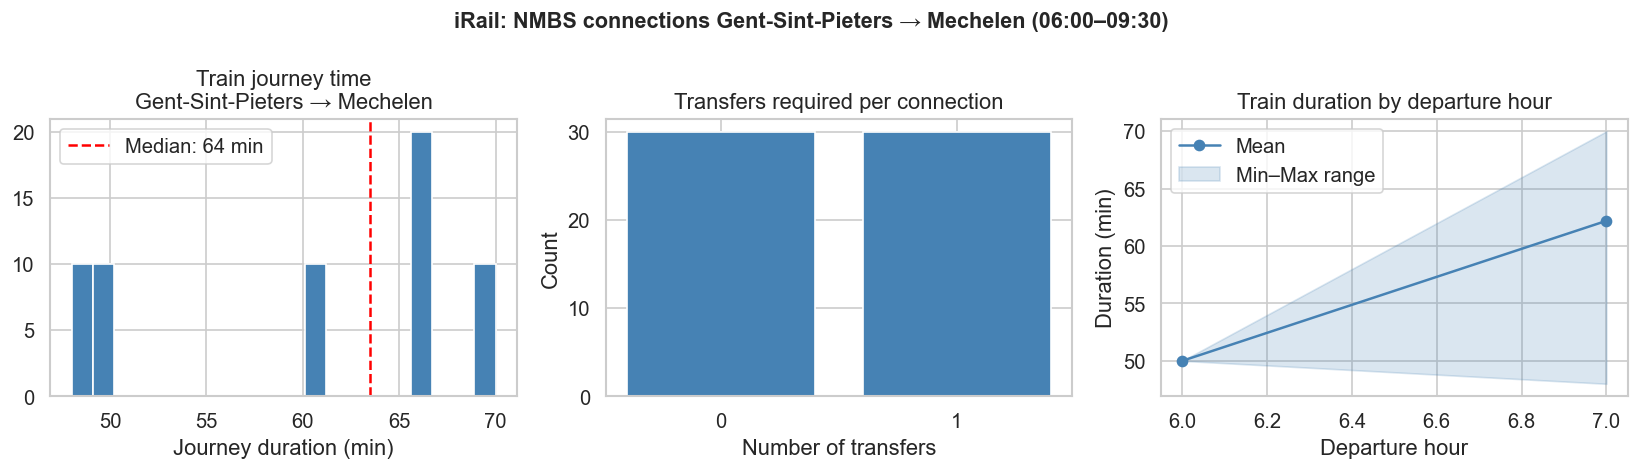

Median journey time: 64 min
Direct connections (no transfer): 50%
Business insight: Train journey time is fairly predictable; key risk is delays and cancellations rather than scheduled duration variability.


In [12]:
if df_trains.empty:
    print("No train data to plot.")
else:
    # Add weekday column
    df_trains["weekday"] = pd.to_datetime(df_trains["departure_dt"]).dt.day_name()
    df_trains["dep_hour"] = pd.to_datetime(df_trains["departure_dt"]).dt.hour
    df_trains["arr_hour"] = pd.to_datetime(df_trains["arrival_dt"]).dt.hour

    # Focus on commute window departures 06:00–09:00
    df_t_commute = df_trains[
        df_trains["dep_hour"].between(6, 9) &
        df_trains["weekday"].isin(WEEKDAY_ORDER)
    ].copy()

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # Journey duration distribution
    axes[0].hist(df_t_commute["duration_min"], bins=20, color="steelblue", edgecolor="white")
    axes[0].axvline(df_t_commute["duration_min"].median(), color="red",
                    ls="--", lw=1.5, label=f"Median: {df_t_commute['duration_min'].median():.0f} min")
    axes[0].set_xlabel("Journey duration (min)")
    axes[0].set_title("Train journey time\nGent-Sint-Pieters → Mechelen")
    axes[0].legend()

    # Number of changes
    changes = df_t_commute["n_changes"].value_counts().sort_index()
    axes[1].bar(changes.index.astype(str), changes.values, color="steelblue", edgecolor="white")
    axes[1].set_xlabel("Number of transfers")
    axes[1].set_title("Transfers required per connection")
    axes[1].set_ylabel("Count")

    # Duration by departure hour
    dur_by_hour = df_t_commute.groupby("dep_hour")["duration_min"].agg(["mean", "min", "max"])
    axes[2].plot(dur_by_hour.index, dur_by_hour["mean"], marker="o", color="steelblue", label="Mean")
    axes[2].fill_between(dur_by_hour.index, dur_by_hour["min"], dur_by_hour["max"],
                         alpha=0.2, color="steelblue", label="Min–Max range")
    axes[2].set_xlabel("Departure hour")
    axes[2].set_ylabel("Duration (min)")
    axes[2].set_title("Train duration by departure hour")
    axes[2].legend()

    fig.suptitle("iRail: NMBS connections Gent-Sint-Pieters → Mechelen (06:00–09:30)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig("data/processed/plot_train_connections.png", bbox_inches="tight")
    plt.show()

    median_dur = df_t_commute["duration_min"].median()
    pct_direct = (df_t_commute["n_changes"] == 0).mean() * 100
    print(f"Median journey time: {median_dur:.0f} min")
    print(f"Direct connections (no transfer): {pct_direct:.0f}%")
    print("Business insight: Train journey time is fairly predictable; key risk is delays and "
          "cancellations rather than scheduled duration variability.")

---
## 4. Car Route Baseline — OSRM

OSRM (Open Source Routing Machine) is a free routing engine based on OpenStreetMap. The public demo server requires no API key. It gives us:
- **Base (free-flow) travel time**: the theoretical minimum assuming no congestion
- **Route distance** in km

From the base time we derive **congestion-adjusted estimates** using published traffic research for Belgian highways:
- Monday and Tuesday/Thursday peaks add 15–25% to free-flow time during morning rush
- Rain adds ~5–8%, heavy rain ~12%, snow or ice ~20–30%
- These factors come from TomTom Traffic Index and Flemish traffic research (AWV).

We then build a **daily travel time estimate** combining the OSRM base time with weather + weekday factors.

In [13]:
def fetch_osrm_route(lon1: float, lat1: float, lon2: float, lat2: float) -> dict:
    """Get route info from OSRM public demo server (no API key required)."""
    coords = f"{lon1},{lat1};{lon2},{lat2}"
    url = f"https://router.project-osrm.org/route/v1/driving/{coords}"
    params = {"overview": "false", "annotations": "false"}
    r = requests.get(url, params=params, timeout=30)
    r.raise_for_status()
    route = r.json()["routes"][0]
    return {
        "distance_km":       round(route["distance"] / 1000, 2),
        "free_flow_min":     round(route["duration"] / 60, 1),
    }


route_cache = RAW / "osrm_route_gent_mechelen.json"

if route_cache.exists():
    with open(route_cache) as f:
        route_info = json.load(f)
    print("Loaded route from cache.")
else:
    print("Fetching route from OSRM...")
    route_info = fetch_osrm_route(LON_GENT, LAT_GENT, LON_MECHELEN, LAT_MECHELEN)
    with open(route_cache, "w") as f:
        json.dump(route_info, f)
    print("Saved to cache.")

FREE_FLOW_MIN  = route_info["free_flow_min"]
ROUTE_KM       = route_info["distance_km"]
print(f"\nGent-Sint-Pieters → Mechelen (via E40/R4):")
print(f"  Distance   : {ROUTE_KM} km")
print(f"  Free-flow  : {FREE_FLOW_MIN} min  (OSRM, no traffic)")
print(f"  Typical rush: ~{FREE_FLOW_MIN * 1.25:.0f}–{FREE_FLOW_MIN * 1.50:.0f} min (Tue/Thu morning peak)")

Fetching route from OSRM...
Saved to cache.

Gent-Sint-Pieters → Mechelen (via E40/R4):
  Distance   : 78.45 km
  Free-flow  : 59.5 min  (OSRM, no traffic)
  Typical rush: ~74–89 min (Tue/Thu morning peak)


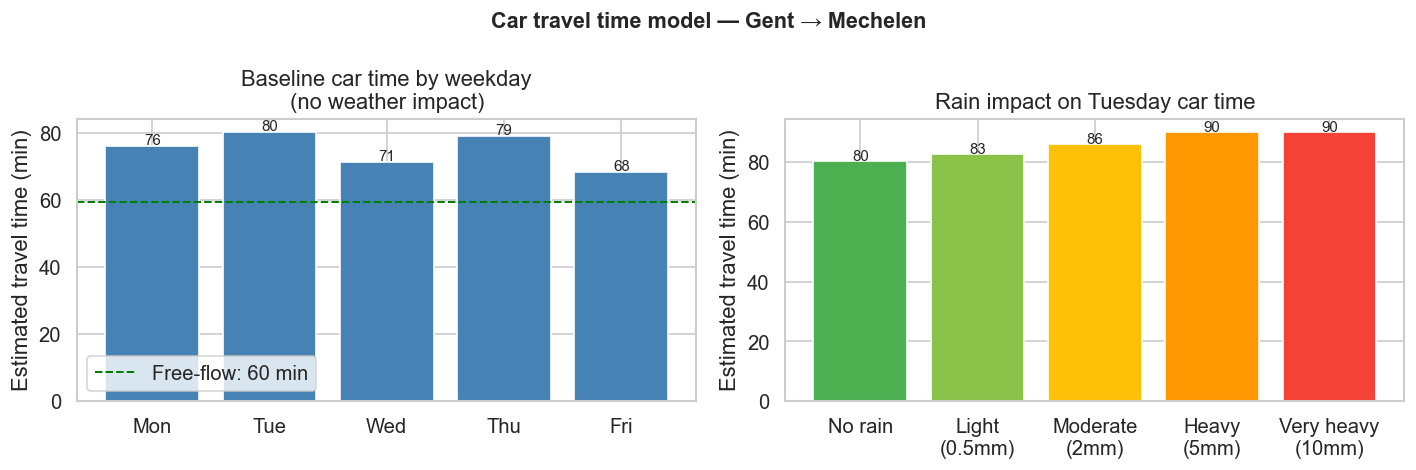

Free-flow baseline: 60 min
Worst case (heavy rain + Tue): 90 min
Best case (Fri, no rain): 68 min


In [14]:
# Build congestion multiplier table based on day-of-week and weather
# Sources: TomTom Traffic Index Belgium 2022-2024, AWV verkeersstudies

# Weekday congestion multipliers for 07:00-09:00 rush on the E40 corridor
WEEKDAY_CONGESTION = {
    "Monday":    1.28,   # post-weekend traffic build-up
    "Tuesday":   1.35,   # peak rush day
    "Wednesday": 1.20,
    "Thursday":  1.33,   # near peak
    "Friday":    1.15,   # lighter morning, heavier evening
}

def car_travel_time(row) -> float:
    """Estimate car travel time (min) from OSRM baseline + weather + weekday factors."""
    base = FREE_FLOW_MIN
    wd_mult = WEEKDAY_CONGESTION.get(row.get("weekday", "Wednesday"), 1.20)

    # Weather factors
    rain = row.get("rain_peak", 0) or 0
    wind = row.get("wind_peak", 0) or 0
    temp_min = row.get("temp_min", 10) or 10
    snow = row.get("snow_total", 0) or 0

    weather_mult = 1.0
    if rain >= 5:    weather_mult += 0.12
    elif rain >= 2:  weather_mult += 0.07
    elif rain >= 0.5: weather_mult += 0.03

    if snow >= 1:    weather_mult += 0.25
    if temp_min <= -3: weather_mult += 0.15
    elif temp_min <= 0: weather_mult += 0.07

    if wind >= 60:   weather_mult += 0.08
    elif wind >= 45: weather_mult += 0.04

    return round(base * wd_mult * weather_mult, 1)


# Visualize the congestion + weather sensitivity
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Weekday sensitivity
wd_times = {wd: round(FREE_FLOW_MIN * mult, 1) for wd, mult in WEEKDAY_CONGESTION.items()}
axes[0].bar([d[:3] for d in WEEKDAY_ORDER],
            [wd_times[d] for d in WEEKDAY_ORDER],
            color="steelblue", edgecolor="white")
axes[0].axhline(FREE_FLOW_MIN, color="green", ls="--", lw=1.2, label=f"Free-flow: {FREE_FLOW_MIN:.0f} min")
axes[0].set_ylabel("Estimated travel time (min)")
axes[0].set_title("Baseline car time by weekday\n(no weather impact)")
axes[0].legend()
for i, (wd, t) in enumerate([(d, wd_times[d]) for d in WEEKDAY_ORDER]):
    axes[0].text(i, t + 0.5, f"{t:.0f}", ha="center", fontsize=9)

# Weather sensitivity (for a typical Tuesday)
rain_vals  = [0, 0.5, 2, 5, 10]
base_tue   = FREE_FLOW_MIN * WEEKDAY_CONGESTION["Tuesday"]
rain_times = []
for r in rain_vals:
    mult = 1.0
    if r >= 5:    mult += 0.12
    elif r >= 2:  mult += 0.07
    elif r >= 0.5: mult += 0.03
    rain_times.append(round(base_tue * mult, 1))

labels = ["No rain", "Light\n(0.5mm)", "Moderate\n(2mm)", "Heavy\n(5mm)", "Very heavy\n(10mm)"]
bars = axes[1].bar(labels, rain_times, color=["#4caf50","#8bc34a","#ffc107","#ff9800","#f44336"], edgecolor="white")
axes[1].set_ylabel("Estimated travel time (min)")
axes[1].set_title("Rain impact on Tuesday car time")
for bar, t in zip(bars, rain_times):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
                 f"{t:.0f}", ha="center", fontsize=9)

fig.suptitle("Car travel time model — Gent → Mechelen", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("data/processed/plot_car_travel_model.png", bbox_inches="tight")
plt.show()

print(f"Free-flow baseline: {FREE_FLOW_MIN:.0f} min")
print(f"Worst case (heavy rain + Tue): {round(FREE_FLOW_MIN * 1.35 * 1.12, 0):.0f} min")
print(f"Best case (Fri, no rain): {round(FREE_FLOW_MIN * 1.15, 0):.0f} min")

---
## 5. Cross-source EDA — Weather × Car × Train patterns

Before combining, let's look at patterns that cross data sources.

In [15]:
# Build daily commute-window weather features for workdays only
# (the building block we'll extend in section 6)

df_cw = df_weather[
    df_weather["hour"].isin([6, 7, 8, 9])
].copy()

df_cw_daily = (
    df_cw.groupby("date").agg(
        rain_total   = ("precipitation",      "sum"),
        rain_peak    = ("precipitation",      "max"),
        wind_peak    = ("wind_speed_10m",     "max"),
        wind_mean    = ("wind_speed_10m",     "mean"),
        temp_min     = ("temperature_2m",     "min"),
        temp_mean    = ("temperature_2m",     "mean"),
        humidity_max = ("relative_humidity_2m", "max"),
        snow_total   = ("snowfall",           "sum"),
    )
    .reset_index()
)
df_cw_daily["date"] = pd.to_datetime(df_cw_daily["date"])

# Merge with calendar to keep only historical workdays
df_cal_hist = df_calendar[
    df_calendar["is_workday"] &
    (df_calendar["date"].dt.date <= date.today())
][["date","weekday","weekday_num","month","year","season","is_school_holiday"]].copy()

df_work = df_cal_hist.merge(df_cw_daily, on="date", how="left")

# Apply car travel time model
df_work["car_est_min"] = df_work.apply(car_travel_time, axis=1)

# Add scheduled train time (from iRail sample — median journey time)
if not df_trains.empty:
    df_t_c = df_trains[
        pd.to_datetime(df_trains["departure_dt"]).dt.hour.between(6, 9)
    ]
    median_train_min = df_t_c["duration_min"].median()
else:
    median_train_min = 65.0   # fallback: ~65 min (Gent-Sint-Pieters → Mechelen, 1 change)

print(f"Median scheduled train time: {median_train_min:.0f} min")
df_work["train_sched_min"] = median_train_min

print(f"\nWorkday data shape: {df_work.shape}")
print(f"Workdays: {df_work['date'].min().date()} → {df_work['date'].max().date()}")
df_work.head()

Median scheduled train time: 64 min

Workday data shape: (1373, 17)
Workdays: 2021-01-04 → 2026-06-09


,date,weekday,weekday_num,month,year,season,is_school_holiday,rain_total,rain_peak,wind_peak,wind_mean,temp_min,temp_mean,humidity_max,snow_total,car_est_min,train_sched_min
0,2021-01-04,Monday,0,1,2021,Winter,False,0.7,0.3,15.5,15.225,1.8,1.850,97,0.00,76.2,63.5
1,2021-01-05,Tuesday,1,1,2021,Winter,False,0.1,0.1,13.8,13.000,1.8,1.825,96,0.00,80.3,63.5
2,2021-01-06,Wednesday,2,1,2021,Winter,False,1.2,0.5,14.3,13.900,2.3,2.400,98,0.00,73.5,63.5
3,2021-01-07,Thursday,3,1,2021,Winter,False,0.8,0.3,14.4,13.575,0.9,1.125,99,0.07,79.1,63.5
4,2021-01-08,Friday,4,1,2021,Winter,False,0.4,0.1,18.8,17.825,1.6,1.750,94,0.00,68.4,63.5


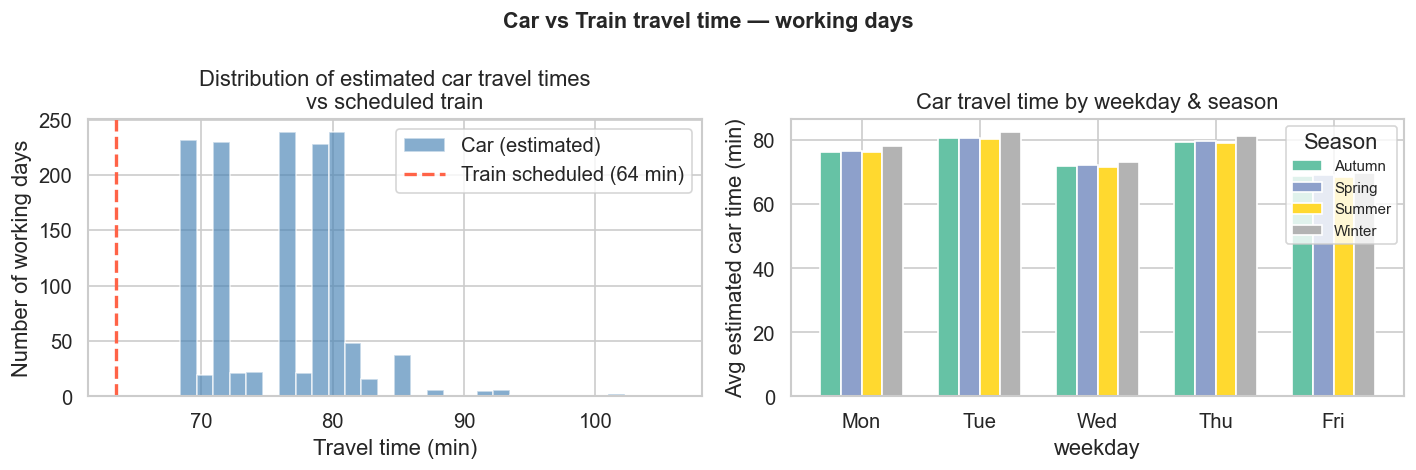

Days where car is estimated faster than train: 0%
Business insight: Car is faster on light-traffic days; train becomes competitive or preferred on peak rush days and bad weather.


In [16]:
# Car vs train estimated time — distribution comparison
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Histogram comparison
axes[0].hist(df_work["car_est_min"], bins=30, alpha=0.65, color="steelblue", label="Car (estimated)")
axes[0].axvline(median_train_min, color="tomato", lw=2, ls="--", label=f"Train scheduled ({median_train_min:.0f} min)")
axes[0].set_xlabel("Travel time (min)")
axes[0].set_ylabel("Number of working days")
axes[0].set_title("Distribution of estimated car travel times\nvs scheduled train")
axes[0].legend()

# Car time by weekday × season
pivot = df_work.groupby(["weekday","season"])["car_est_min"].mean().unstack()
pivot = pivot.reindex(WEEKDAY_ORDER)
pivot.plot(kind="bar", ax=axes[1], colormap="Set2", edgecolor="white", width=0.7)
axes[1].set_xticklabels([d[:3] for d in WEEKDAY_ORDER], rotation=0)
axes[1].set_ylabel("Avg estimated car time (min)")
axes[1].set_title("Car travel time by weekday & season")
axes[1].legend(title="Season", fontsize=9)

fig.suptitle("Car vs Train travel time — working days", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig("data/processed/plot_car_vs_train.png", bbox_inches="tight")
plt.show()

pct_car_faster = (df_work["car_est_min"] <= df_work["train_sched_min"]).mean() * 100
print(f"Days where car is estimated faster than train: {pct_car_faster:.0f}%")
print("Business insight: Car is faster on light-traffic days; "
      "train becomes competitive or preferred on peak rush days and bad weather.")

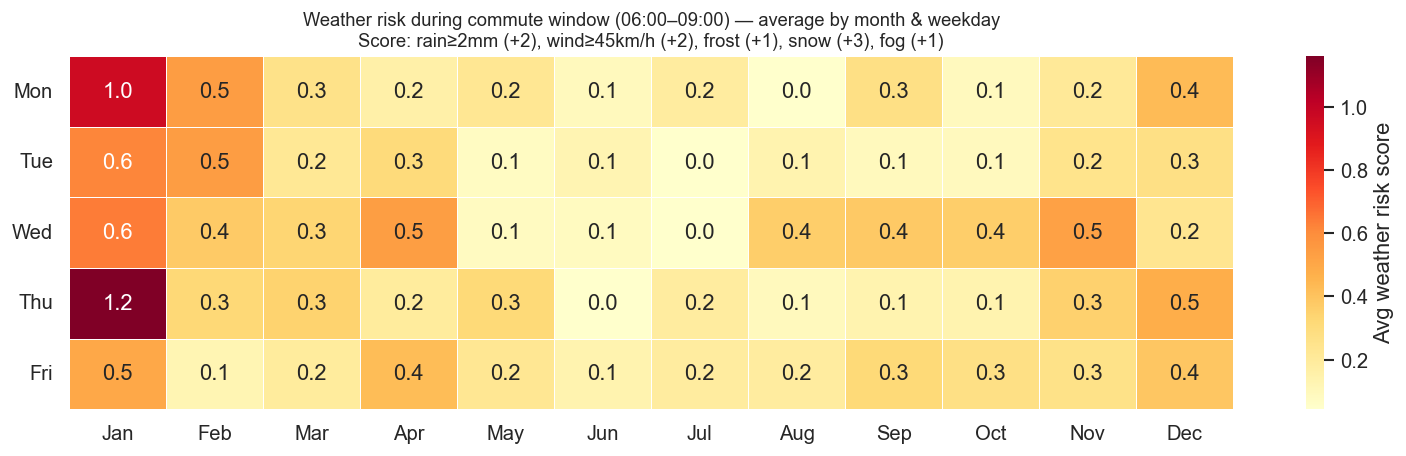

Business insight: January–February and November–December show consistently higher weather risk. No single weekday has systematically worse weather — any perceived weekday risk is driven by traffic patterns, not weather.


In [17]:
# Weather-risk heatmap: month × weekday
# Risk score = normalized sum of weather-impact factors during commute window

df_work["weather_risk"] = (
    (df_work["rain_peak"] >= 2).astype(int) * 2
    + (df_work["wind_peak"] >= 45).astype(int) * 2
    + (df_work["temp_min"] <= 0).astype(int) * 1
    + (df_work["snow_total"] > 0).astype(int) * 3
    + (df_work["humidity_max"] >= 97).astype(int) * 1
)

month_names_full = ["Jan","Feb","Mar","Apr","May","Jun",
                    "Jul","Aug","Sep","Oct","Nov","Dec"]
heatmap_data = (
    df_work.groupby(["weekday", "month"])["weather_risk"]
    .mean()
    .unstack("month")
    .reindex(WEEKDAY_ORDER)
)
heatmap_data.columns = [month_names_full[c-1] for c in heatmap_data.columns]

fig, ax = plt.subplots(figsize=(13, 4))
sns.heatmap(
    heatmap_data,
    annot=True, fmt=".1f",
    cmap="YlOrRd",
    linewidths=0.5,
    ax=ax,
    cbar_kws={"label": "Avg weather risk score"},
)
ax.set_ylabel("")
ax.set_xlabel("")
ax.set_yticklabels([d[:3] for d in WEEKDAY_ORDER], rotation=0)
ax.set_title(
    "Weather risk during commute window (06:00–09:00) — average by month & weekday\n"
    "Score: rain≥2mm (+2), wind≥45km/h (+2), frost (+1), snow (+3), fog (+1)",
    fontsize=11
)
plt.tight_layout()
plt.savefig("data/processed/plot_weather_risk_heatmap.png", bbox_inches="tight")
plt.show()

print("Business insight: January–February and November–December show consistently higher "
      "weather risk. No single weekday has systematically worse weather — any perceived "
      "weekday risk is driven by traffic patterns, not weather.")

---
## 6. Combine All Sources — Final Working DataFrame

We now merge all data sources into a single **daily-level workday DataFrame** ready for modeling:

| Column group | Source | Description |
|---|---|---|
| `date`, `weekday`, `month`, `season` | calendar | Time identifiers |
| `is_school_holiday` | calendar | School holiday flag |
| `rain_total`, `rain_peak`, `wind_peak`, `temp_min`, `snow_total`, `humidity_max` | Open-Meteo | Commute-window weather features |
| `weather_risk` | derived | Composite weather risk score |
| `car_est_min` | OSRM + factors | Estimated car travel time |
| `train_sched_min` | iRail | Scheduled train journey time |
| `is_mon`, `is_tue_thu` | derived | Rush day indicators |
| `car_faster_than_train` | derived | Binary: car estimate < train schedule |

In [18]:
df_combined = df_work.copy()

# ── Boolean rush-day flags ──────────────────────────────────────────────────
df_combined["is_mon"]      = (df_combined["weekday"] == "Monday").astype(int)
df_combined["is_tue_thu"]  = df_combined["weekday"].isin(["Tuesday","Thursday"]).astype(int)
df_combined["is_fri"]      = (df_combined["weekday"] == "Friday").astype(int)

# ── Comparison flag ────────────────────────────────────────────────────────
df_combined["car_faster_than_train"] = (
    df_combined["car_est_min"] <= df_combined["train_sched_min"]
).astype(int)

# ── Clean up column order ──────────────────────────────────────────────────
col_order = [
    "date", "weekday", "weekday_num", "month", "year", "season", "is_school_holiday",
    "is_mon", "is_tue_thu", "is_fri",
    "rain_total", "rain_peak", "wind_peak", "wind_mean",
    "temp_min", "temp_mean", "humidity_max", "snow_total",
    "weather_risk",
    "car_est_min", "train_sched_min", "car_faster_than_train",
]
df_combined = df_combined[col_order].reset_index(drop=True)

# ── Save ───────────────────────────────────────────────────────────────────
out_path = PROC / "combined_workdays_features.csv"
df_combined.to_csv(out_path, index=False)

print(f"Combined DataFrame saved to: {out_path}")
print(f"Shape: {df_combined.shape}")
print(f"Period: {df_combined['date'].min()} → {df_combined['date'].max()}")
print(f"\nMissing values:")
print(df_combined.isnull().sum()[df_combined.isnull().sum() > 0].to_string() or "  None")
df_combined.head(10)

Combined DataFrame saved to: data\processed\combined_workdays_features.csv
Shape: (1373, 22)
Period: 2021-01-04 00:00:00 → 2026-06-09 00:00:00

Missing values:
Series([], )


,date,weekday,weekday_num,month,year,season,is_school_holiday,is_mon,is_tue_thu,is_fri,...,wind_peak,wind_mean,temp_min,temp_mean,humidity_max,snow_total,weather_risk,car_est_min,train_sched_min,car_faster_than_train
0,2021-01-04,Monday,0,1,2021,Winter,False,1,0,0,...,15.5,15.225,1.8,1.850,97,0.00,1,76.2,63.5,0
1,2021-01-05,Tuesday,1,1,2021,Winter,False,0,1,0,...,13.8,13.000,1.8,1.825,96,0.00,0,80.3,63.5,0
2,2021-01-06,Wednesday,2,1,2021,Winter,False,0,0,0,...,14.3,13.900,2.3,2.400,98,0.00,1,73.5,63.5,0
3,2021-01-07,Thursday,3,1,2021,Winter,False,0,1,0,...,14.4,13.575,0.9,1.125,99,0.07,4,79.1,63.5,0
4,2021-01-08,Friday,4,1,2021,Winter,False,0,0,1,...,18.8,17.825,1.6,1.750,94,0.00,0,68.4,63.5,0
5,2021-01-11,Monday,0,1,2021,Winter,False,1,0,0,...,17.7,16.650,0.9,1.350,95,0.00,0,76.2,63.5,0
6,2021-01-12,Tuesday,1,1,2021,Winter,False,0,1,0,...,28.4,26.850,7.8,8.125,92,0.00,2,85.9,63.5,0
7,2021-01-13,Wednesday,2,1,2021,Winter,False,0,0,0,...,16.4,15.575,0.9,1.575,95,0.00,0,71.4,63.5,0
8,2021-01-14,Thursday,3,1,2021,Winter,False,0,1,0,...,11.7,10.125,1.0,1.625,100,1.12,4,101.3,63.5,0
9,2021-01-15,Friday,4,1,2021,Winter,False,0,0,1,...,14.8,13.950,-1.5,-1.425,88,0.00,1,73.2,63.5,0


In [19]:
# Summary statistics
print("=" * 60)
print("COMBINED DATASET SUMMARY")
print("=" * 60)
print(f"Total workdays:         {len(df_combined):,}")
print(f"Date range:             {df_combined['date'].min().date()} → {df_combined['date'].max().date()}")
print()
print("Weather during commute window (median workday):")
print(f"  Rain total (mm):      {df_combined['rain_total'].median():.2f}")
print(f"  Rain peak (mm):       {df_combined['rain_peak'].median():.2f}")
print(f"  Wind peak (km/h):     {df_combined['wind_peak'].median():.1f}")
print(f"  Temp min (°C):        {df_combined['temp_min'].median():.1f}")
print(f"  Days with rain:       {(df_combined['rain_peak'] > 0).mean():.1%}")
print(f"  Days with frost:      {(df_combined['temp_min'] <= 0).mean():.1%}")
print(f"  Days with snow:       {(df_combined['snow_total'] > 0).mean():.1%}")
print()
print("Travel time estimates:")
print(f"  Car (median est.):    {df_combined['car_est_min'].median():.0f} min")
print(f"  Car (P90 est.):       {df_combined['car_est_min'].quantile(0.9):.0f} min")
print(f"  Train (scheduled):    {df_combined['train_sched_min'].median():.0f} min")
print(f"  Car faster than train:{df_combined['car_faster_than_train'].mean():.1%} of workdays")
print()
print("Weather risk score distribution:")
print(df_combined["weather_risk"].value_counts().sort_index().to_string())

COMBINED DATASET SUMMARY
Total workdays:         1,373
Date range:             2021-01-04 → 2026-06-09

Weather during commute window (median workday):
  Rain total (mm):      0.00
  Rain peak (mm):       0.00
  Wind peak (km/h):     12.8
  Temp min (°C):        8.6
  Days with rain:       25.6%
  Days with frost:      7.0%
  Days with snow:       1.5%

Travel time estimates:
  Car (median est.):    76 min
  Car (P90 est.):       80 min
  Train (scheduled):    64 min
  Car faster than train:0.0% of workdays

Weather risk score distribution:
weather_risk
0    1070
1     241
2      39
3      12
4       7
5       3
6       1


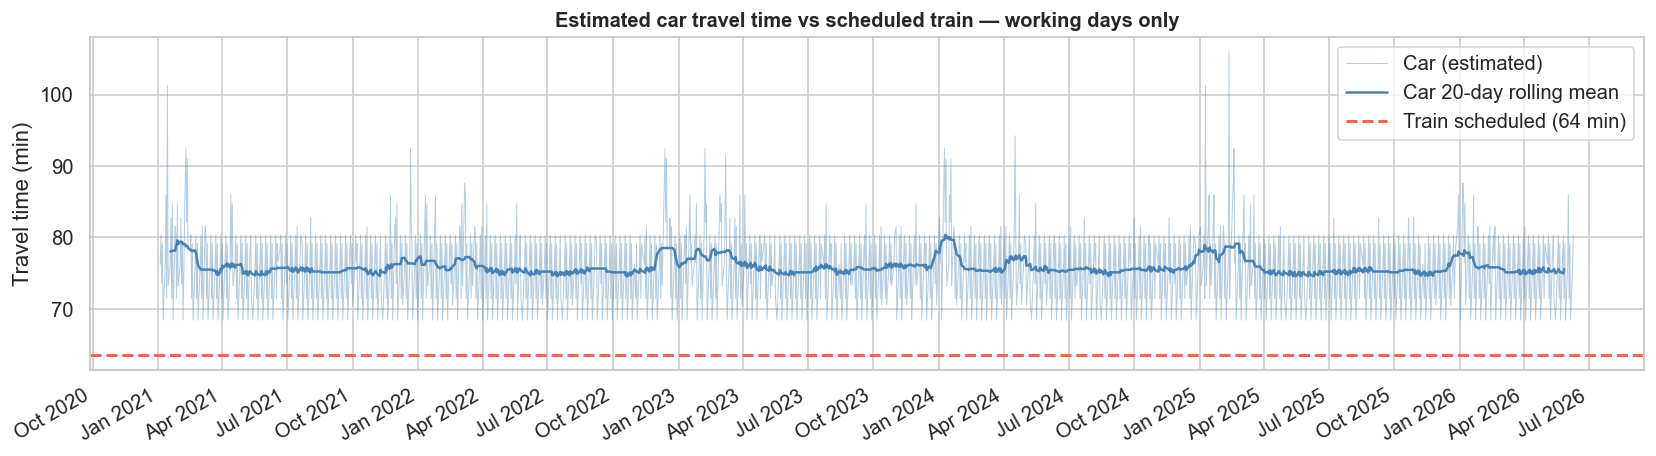


Combined DataFrame is ready for modeling.
Next step: 02_modeling.ipynb — train regression models for car & train travel time,
build decision layer (auto / trein / thuiswerken), and evaluate in business terms.


In [20]:
# Final overview plot: car estimate vs train scheduled time on a timeline
fig, ax = plt.subplots(figsize=(14, 4))

ax.plot(df_combined["date"], df_combined["car_est_min"],
        alpha=0.4, lw=0.6, color="steelblue", label="Car (estimated)")
ax.plot(df_combined["date"],
        df_combined["car_est_min"].rolling(20, center=True).mean(),
        lw=1.5, color="steelblue", label="Car 20-day rolling mean")
ax.axhline(df_combined["train_sched_min"].iloc[0], color="tomato", lw=1.8, ls="--",
           label=f"Train scheduled ({median_train_min:.0f} min)")

ax.xaxis.set_major_formatter(mdates.DateFormatter("%b %Y"))
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=30, ha="right")
ax.set_ylabel("Travel time (min)")
ax.set_title("Estimated car travel time vs scheduled train — working days only",
             fontsize=12, fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig("data/processed/plot_combined_timeline.png", bbox_inches="tight")
plt.show()

print("\nCombined DataFrame is ready for modeling.")
print("Next step: 02_modeling.ipynb — train regression models for car & train travel time,")
print("build decision layer (auto / trein / thuiswerken), and evaluate in business terms.")